# Preparing libraries and imports

In [29]:
import cuequivariance as cue
import cuequivariance_torch as cuet
import torch
torch.cuda.is_available()

from mace import data, modules, tools
import numpy as np
import torch
import torch.nn.functional
from e3nn import o3
from matplotlib import pyplot as plt
import ase.io
%matplotlib inline
from ase.visualize import view
from scipy.spatial.transform import Rotation

from mace.tools import torch_geometric
torch.set_default_dtype(torch.float64)
import warnings
warnings.filterwarnings("ignore")

# Preparing Embeddings

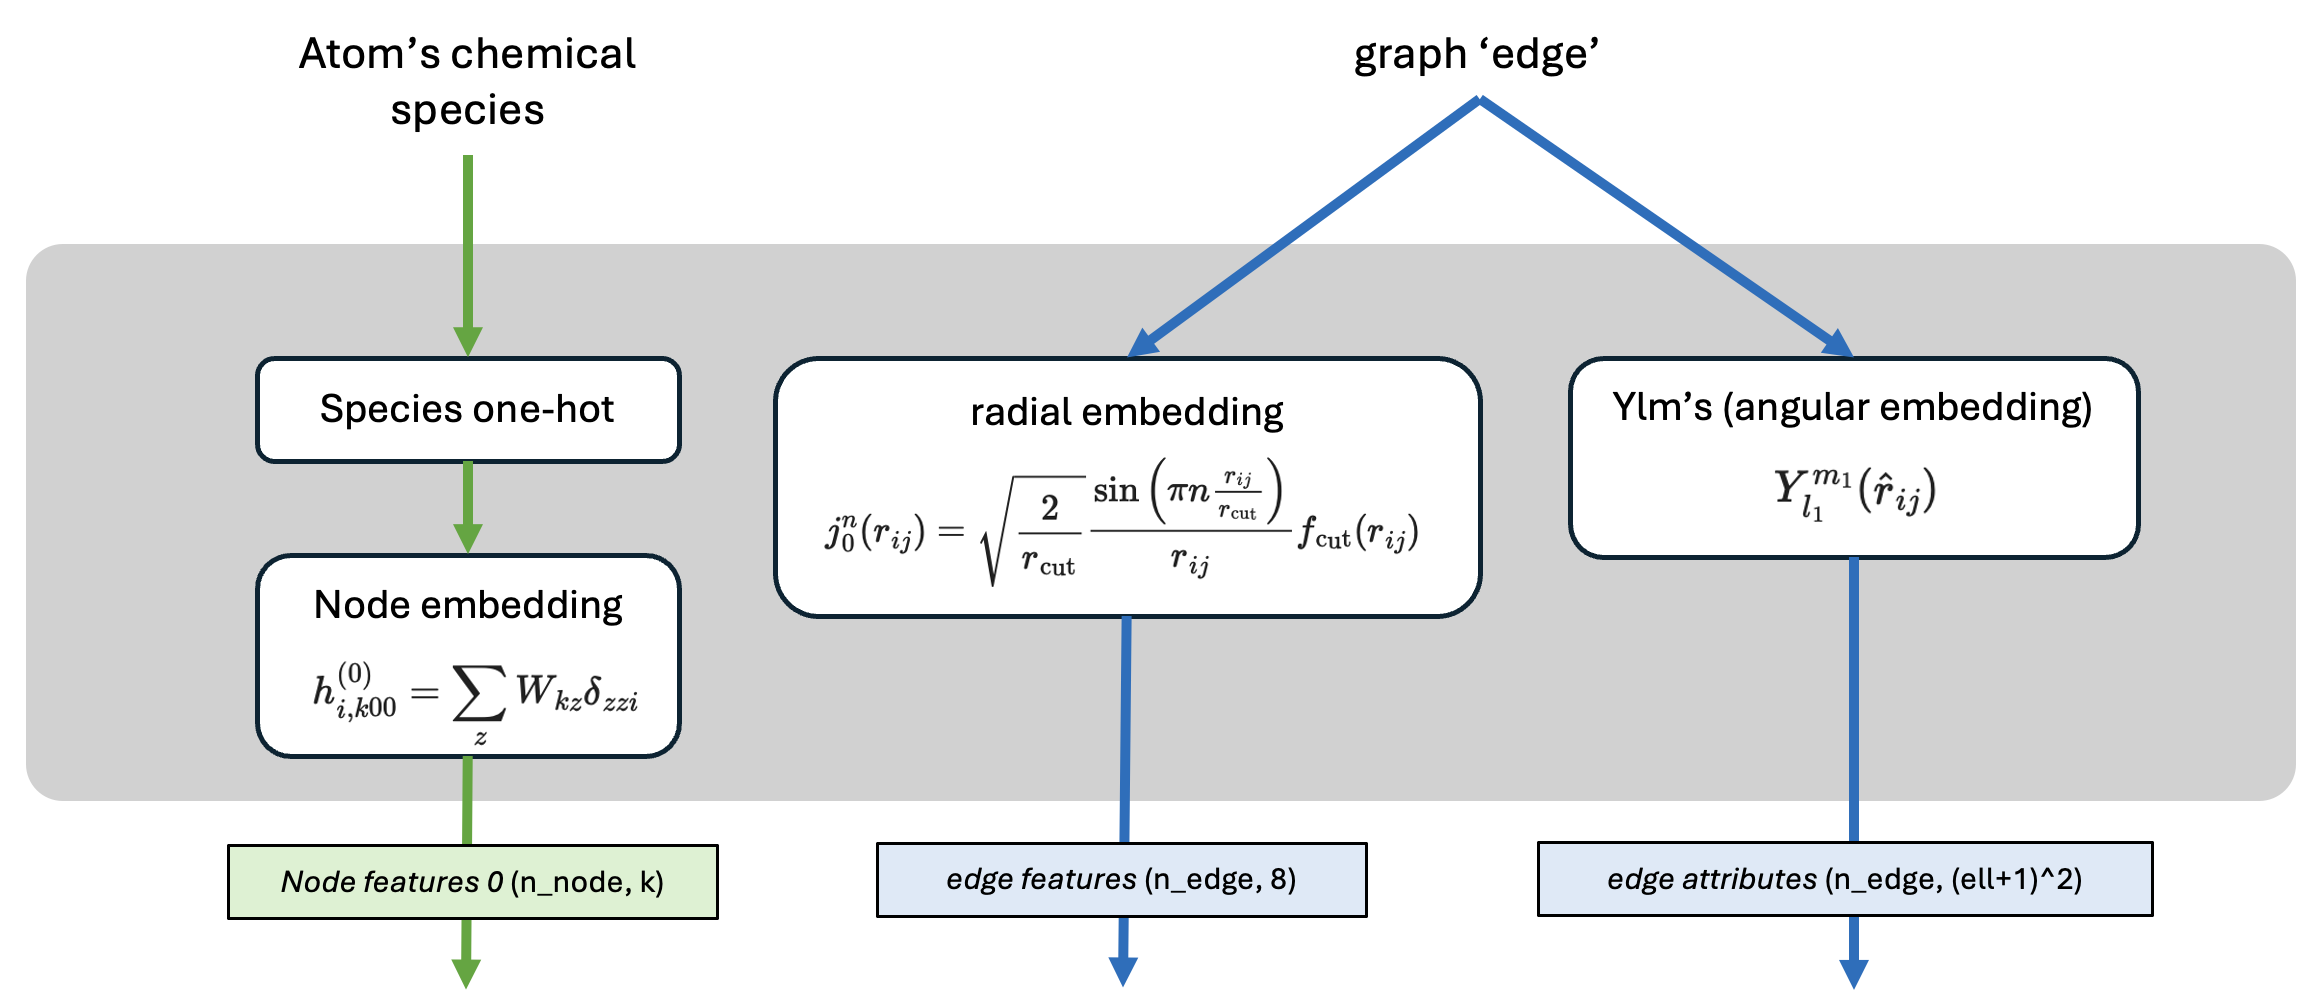

In [30]:
# creating some dummy atoms ie number of atoms
# creating some dummy edges ie number of edges

# let's make 100 edges and 10 nodes
num_edges = 100
num_nodes = 10
num_channels = 8 # these are the channels functions called k
num_basis_functions = 8

node_features = torch.randn(num_nodes, num_channels) # shape: (num_nodes, k)
print(node_features.shape)
edge_features = torch.randn(num_edges, num_basis_functions) # shape: (num_edges, 8)
print(edge_features.shape)
edge_attributes = torch.randn(num_edges, num_channels +1) # shape: (num_edges, dim_sh)
print(edge_attributes.shape)


torch.Size([10, 8])
torch.Size([100, 8])
torch.Size([100, 9])


# Preparing Interaction


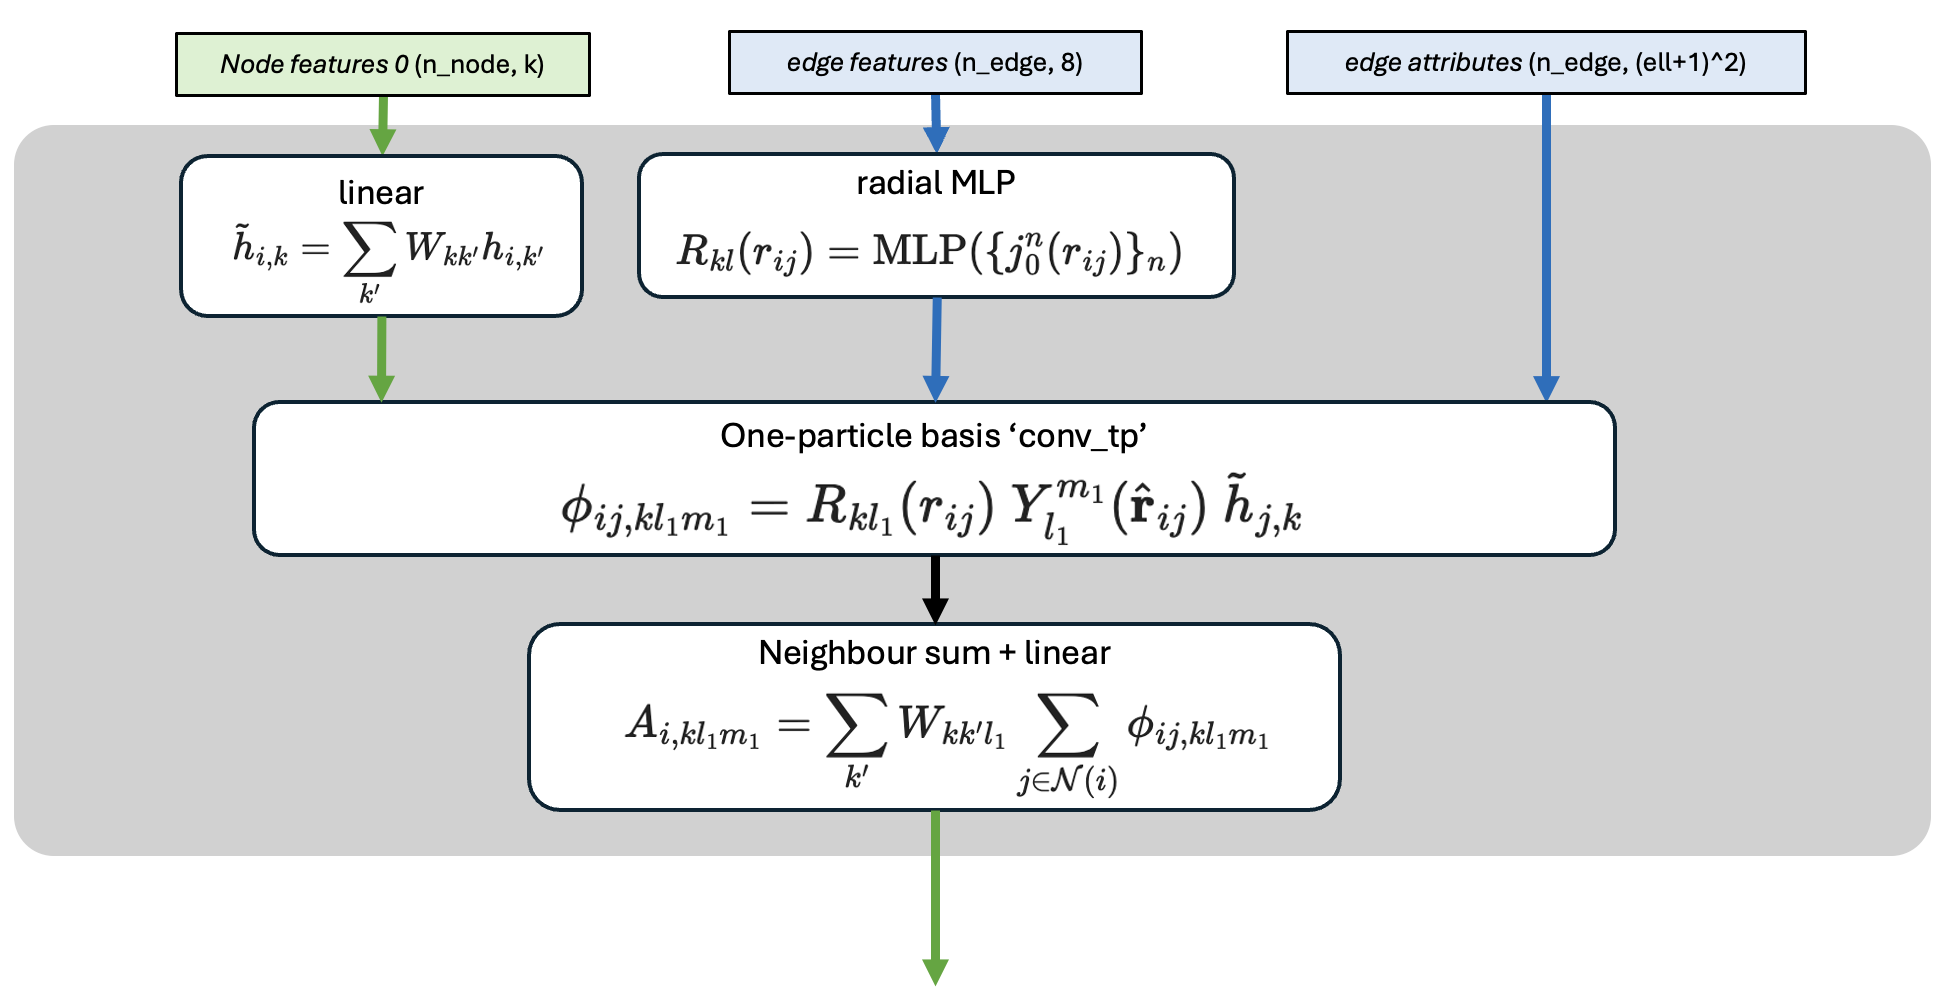

In [2]:
import torch
from e3nn import o3
# from mace.modules.wrapper_ops import CuEquivarianceConfig, OEQConfig
from mace.modules.blocks import RealAgnosticInteractionBlock
# from mace.modules.tp_utils import tp_out_irreps_with_instructions  # wherever you import that helper


In [3]:

import cuequivariance_torch as cuet  # for the cuETensorProduct fusion wrapper
import cuequivariance as cue

In [4]:
import types


def with_cueq_conv_fusion(conv_tp: torch.nn.Module) -> torch.nn.Module:
    """Wraps a cuet.ConvTensorProduct to use conv fusion"""
    conv_tp.original_forward = conv_tp.forward

    def forward(
        self,
        node_feats: torch.Tensor,
        edge_attrs: torch.Tensor,
        tp_weights: torch.Tensor,
        edge_index: torch.Tensor,
    ) -> torch.Tensor:
        sender = edge_index[0]
        receiver = edge_index[1]
        return self.original_forward(
            [tp_weights, node_feats, edge_attrs],
            {1: sender},
            {0: node_feats},
            {0: receiver},
        )

    conv_tp.forward = types.MethodType(forward, conv_tp)
    return conv_tp

## Define metrics

In [5]:
def get_relative_error(ref_tensor: torch.Tensor, comp_tensor: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
    error = (ref_tensor - comp_tensor).abs().max()
    mean = ref_tensor.abs().mean()
    relative_error = error / (mean + 1e-12)
    return error, relative_error

In [6]:
def get_memory_and_time_usage(device: str, task_name: callable):
    if device.startswith('cuda'):
        torch.cuda.reset_peak_memory_stats(device)
        start = torch.cuda.Event(enable_timing=True)
        end = torch.cuda.Event(enable_timing=True)
        start.record()
        task_name
        end.record()
        torch.cuda.synchronize()
        t = start.elapsed_time(end)
        m = torch.cuda.max_memory_allocated(device)
        return t, m
    else:
        import time
        t = time.perf_counter()
        task_name()
        t = (time.perf_counter() - t) * 1000
        m = 0
        return t, m

## This for the first layer of the interaction block

In [9]:
import torch
from e3nn import o3
import cuequivariance   as cue
import cuequivariance_torch as cuet
import copy

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(0)

in_ir, attr_ir, out_ir = (
    o3.Irreps("8x0e"),
    o3.Irreps.spherical_harmonics(1),
    o3.Irreps("4x0e+4x1o"),
)
desc = cue.descriptors.channelwise_tensor_product(
    cue.Irreps("O3", in_ir),
    cue.Irreps("O3", attr_ir),
    cue.Irreps("O3", out_ir),
)

poly64 = cuet.SegmentedPolynomial(
    desc.flatten_coefficient_modes()
        .squeeze_modes()
        .polynomial,
    math_dtype=torch.float64,
    output_dtype_map=[-1]
).to(device).double()

fused64 = with_cueq_conv_fusion(poly64)

num_nodes, num_edges = 10, 100
node_feats64 = torch.randn(num_nodes, in_ir.dim,    device=device, dtype=torch.float64)
edge_attrs64 = torch.randn(num_edges, attr_ir.dim,  device=device, dtype=torch.float64)
tpw64 = torch.randn(num_edges, 2048, device=device).to(torch.float64)

edge_index64 = torch.randint(0, num_nodes, (2, num_edges),
                             device=device, dtype=torch.int64)

# helper to run one precision
def run_precision(fused_ref, dtype):
    # if dtype is a string and tf32 activate it
    if dtype == "tf32" and device.startswith("cuda"):
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32   = True
        dtype = torch.float32
    # deep‐copy then cast the module to dtype
    fused = copy.deepcopy(fused_ref).to(dtype)
    # cast inputs to dtype
    nf = node_feats64.to(dtype)
    ea = edge_attrs64.to(dtype)
    tw = tpw64       .to(dtype)
    ei = edge_index64  # always int64
    # FP32 baseline without TF32:
    if dtype is torch.float32 and device.startswith("cuda"):
        torch.backends.cuda.matmul.allow_tf32 = False
        torch.backends.cudnn.allow_tf32   = False
    return fused(nf, ea, tw, ei)

out64 = run_precision(fused64, torch.float64)[0]

results = []
for name, dtype in [("FP32", torch.float32), ("TF32", "tf32"), ("FP16", torch.float16), ("BF16", torch.bfloat16)]:
    if dtype in ["tf32", torch.float16, torch.bfloat16] and not device.startswith("cuda"):
        continue
    def task():
        return run_precision(fused64, dtype)[0]
    t, m = get_memory_and_time_usage(device, task)
    out = task()
    err, rel = get_relative_error(out64, out)
    results.append((name, t, m, err, rel))

for name, t, m, err, rel in results:
    print(f"{name}: time={t} ms, memory={m/1e6} MB, max_abs_error={err}, relative_error={rel}")


FP32: time=0.023296000435948372 ms, memory=1.66144 MB, max_abs_error=4.258103656340495e-07, relative_error=2.052885127968988e-07
TF32: time=0.014911999925971031 ms, memory=1.66144 MB, max_abs_error=4.258103647458711e-07, relative_error=2.0528851236869685e-07
FP16: time=0.014495999552309513 ms, memory=1.662464 MB, max_abs_error=0.008753699907073198, relative_error=0.004220268411544066
BF16: time=0.01462399959564209 ms, memory=1.663488 MB, max_abs_error=0.03628521360263548, relative_error=0.017493556141854508


## Benchmarking with different numerical precision

In [ ]:
# writing the different test

def get_memory_and_time_usage(device, task_name):
    if device.startswith('cuda'):
        torch.cuda.reset_peak_memory_stats(device)
        start = torch.cuda.Event(enable_timing=True)
        end = torch.cuda.Event(enable_timing=True)
        start.record()
        task_name
        end.record()
        torch.cuda.synchronize()
        t = start.elapsed_time(end)
        m = torch.cuda.max_memory_allocated(device)
        return t, m
    else:
        import time
        t = time.perf_counter()
        task_name()
        t = (time.perf_counter() - t) * 1000
        m = 0
        return t, m
    
def get_relative_error(ref_tensor, comp_tensor):
    error = (ref_tensor - comp_tensor).abs().max()
    mean = ref_tensor.abs().mean()
    relative_error = error / (mean + 1e-12)
    return error, relative_error


In [ ]:
precision = ['fp64', 'fp32', 'bf16', 'fp16', 'tf32']

results = {}

with torch.no_grad():
    for dtype in precision:
        # create precision lable for metrics
        precision_label = str(dtype)
        if dtype == 'fp64':
            dtype = torch.float64
        elif dtype == 'fp32':
            dtype = torch.float32
        elif dtype == 'bf16' and device.startswith('cuda'):
            dtype = torch.bfloat16
        elif dtype == 'fp16':
            dtype = torch.float16
        elif dtype == 'tf32':
            dtype = torch.float32
            torch.backends.cuda.matmul.allow_tf32 = True
            torch.backends.cudnn.allow_tf32 = True
        else:
            raise ValueError(f"Unsupported precision: {dtype}")

    

NameError: name 'torch' is not defined

---

In [2]:
tp = cuet.ChannelWiseTensorProduct(
    cue.Irreps("O3", in_ir),
    cue.Irreps("O3", attr_ir),
    cue.Irreps("O3", out_ir),
    layout=cue.ir_mul,
    shared_weights=True,
    internal_weights=False,
    device=device,
    dtype=torch.get_default_dtype(),
    math_dtype=torch.get_default_dtype(),
    use_fallback=False
)
tp(node_feats[edge_index[0]], edge_attrs, tp_weights)

NameError: name 'cuet' is not defined